# Person 3 — Exploration Notebook

This notebook verifies the P2 handoff artifacts and demonstrates Person 3's three graph analyses:
- **Graph 10**: Community detection (Louvain vs Leiden vs Girvan-Newman) and comparison against null models
- **Graph 11**: Structural balance vs. edge threshold sweep
- **Graph 6**: Reordered correlation heatmap

All production code lives in `src/person3/`. This notebook just calls `run()` from each module and displays results inline.

In [1]:
import numpy as np
import json
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

ROOT = Path("..")
ARTIFACTS = ROOT / "artifacts"
sys.path.insert(0, str(ROOT.absolute()))

print("=== Artifacts check ===")
print("corr_denoised.npy shape:", np.load(ARTIFACTS / "corr_denoised.npy").shape)
threshold = json.loads((ARTIFACTS / "threshold.json").read_text())['chosen_threshold']
print("threshold.json: chosen_threshold =", threshold)

=== Artifacts check ===
corr_denoised.npy shape: (60, 60)
threshold.json: chosen_threshold = 0.22


---
## Graph 10: Community Detection & Null Model Comparison

### Algorithm Comparison: Louvain vs Leiden vs Girvan-Newman

We compare three fundamentally different community detection methods:

| Algorithm | Strategy | Complexity | Key property |
|---|---|---|---|
| **Louvain** | Agglomerative, greedy Q-maximisation | O(n log n) | Fast, but can produce poorly-connected communities |
| **Leiden** | Agglomerative + refinement phase | O(n log n) | Guarantees well-connected communities; best Q |
| **Girvan-Newman** | Divisive, edge-betweenness removal | O(m²n) | Unique: provides full Q(k) curve; no k preset needed |

**What the Q value means:** Modularity Q measures how much more densely connected nodes are within their assigned community compared to a random graph with the same degree sequence. Q ∈ [-1, 1]; higher is better. Values > 0.3 are considered meaningful structure.

**What k means:** The number of communities found. All three algorithms independently agree on k=15, which is strong evidence that 15 is a genuine structural feature of the network.

**Why Leiden > Louvain:** Louvain's greedy merge phase can get stuck in local optima where a community appears dense externally but is internally fragmented. Leiden adds a refinement step that sub-divides merged super-nodes to escape these traps, finding Q=0.491 vs Louvain's Q=0.472.

**Why GN's Q curve is uniquely informative:** Unlike Louvain/Leiden which give one partition, GN reveals the full landscape of how modularity varies with k. A sharp peak means there is one natural scale of community structure; a flat curve means the network has no preferred scale.

In [2]:
import src.person3.graph_10
importlib.reload(src.person3.graph_10)
from src.person3.graph_10 import run as run_g10

stats_g10 = run_g10()

print("\n=== Algorithm Comparison ===")
print(f"  Louvain       : k={stats_g10['k_louvain']:2d}, Q={stats_g10['Q_louvain']:.4f}  | greedy agglomerative")
print(f"  Leiden        : k={stats_g10['k_leiden']:2d}, Q={stats_g10['Q_leiden']:.4f}  | agglomerative + refinement (BEST Q)")
print(f"  Girvan-Newman : k={stats_g10['k_girvan_newman']:2d}, Q={stats_g10['Q_girvan_newman']:.4f}  | divisive, betweenness-based")
print(f"\n  All three algorithms agree on k={stats_g10['k_leiden']} communities.")
print(f"  Leiden improvement over Louvain: +{stats_g10['Q_leiden'] - stats_g10['Q_louvain']:.4f} (+{(stats_g10['Q_leiden']/stats_g10['Q_louvain']-1)*100:.1f}%)")

  item graph: 60 nodes, 131 edges at |r| > 0.22

  === Community detection comparison ===
  Louvain: 15 communities, Q = 0.4721
  Leiden : 15 communities, Q = 0.4910


  Louvain       : k=15, Q=0.4721  | Approach: agglomerative, greedy modularity
  Leiden        : k=15, Q=0.4910  | Approach: agglomerative + refinement phase
  Girvan-Newman : k=15, Q=0.4471  | Approach: divisive, edge-betweenness removal


  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_10_algorithm_comparison.png / .pdf
  Leiden NMI (community vs topic block) = 0.2046

  Leiden NMI (community vs topic block) = 0.2046
  computing null distributions for item network (using Leiden)...
  permutation null: 200 replicates loaded


    permutation replicate 50/200


    permutation replicate 100/200


    permutation replicate 150/200


    permutation replicate 200/200
  rewiring null: 200 replicates...


  ER null: 200 replicates...



  null                     mean       sd        z        p
  permutation             0.629    0.044    -3.14    1.000
  rewiring                0.333    0.013    12.13    0.005
  ER                      0.420    0.016     4.46    0.005



  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_10_communities_nulls.png / .pdf
  wrote artifacts/graph10_communities.json

=== Algorithm Comparison ===
  Louvain       : k=15, Q=0.4721  | greedy agglomerative
  Leiden        : k=15, Q=0.4910  | agglomerative + refinement (BEST Q)
  Girvan-Newman : k=15, Q=0.4471  | divisive, betweenness-based

  All three algorithms agree on k=15 communities.
  Leiden improvement over Louvain: +0.0189 (+4.0%)


Three-algorithm comparison figure (modularity bar + GN Q(k) curve + community sizes):


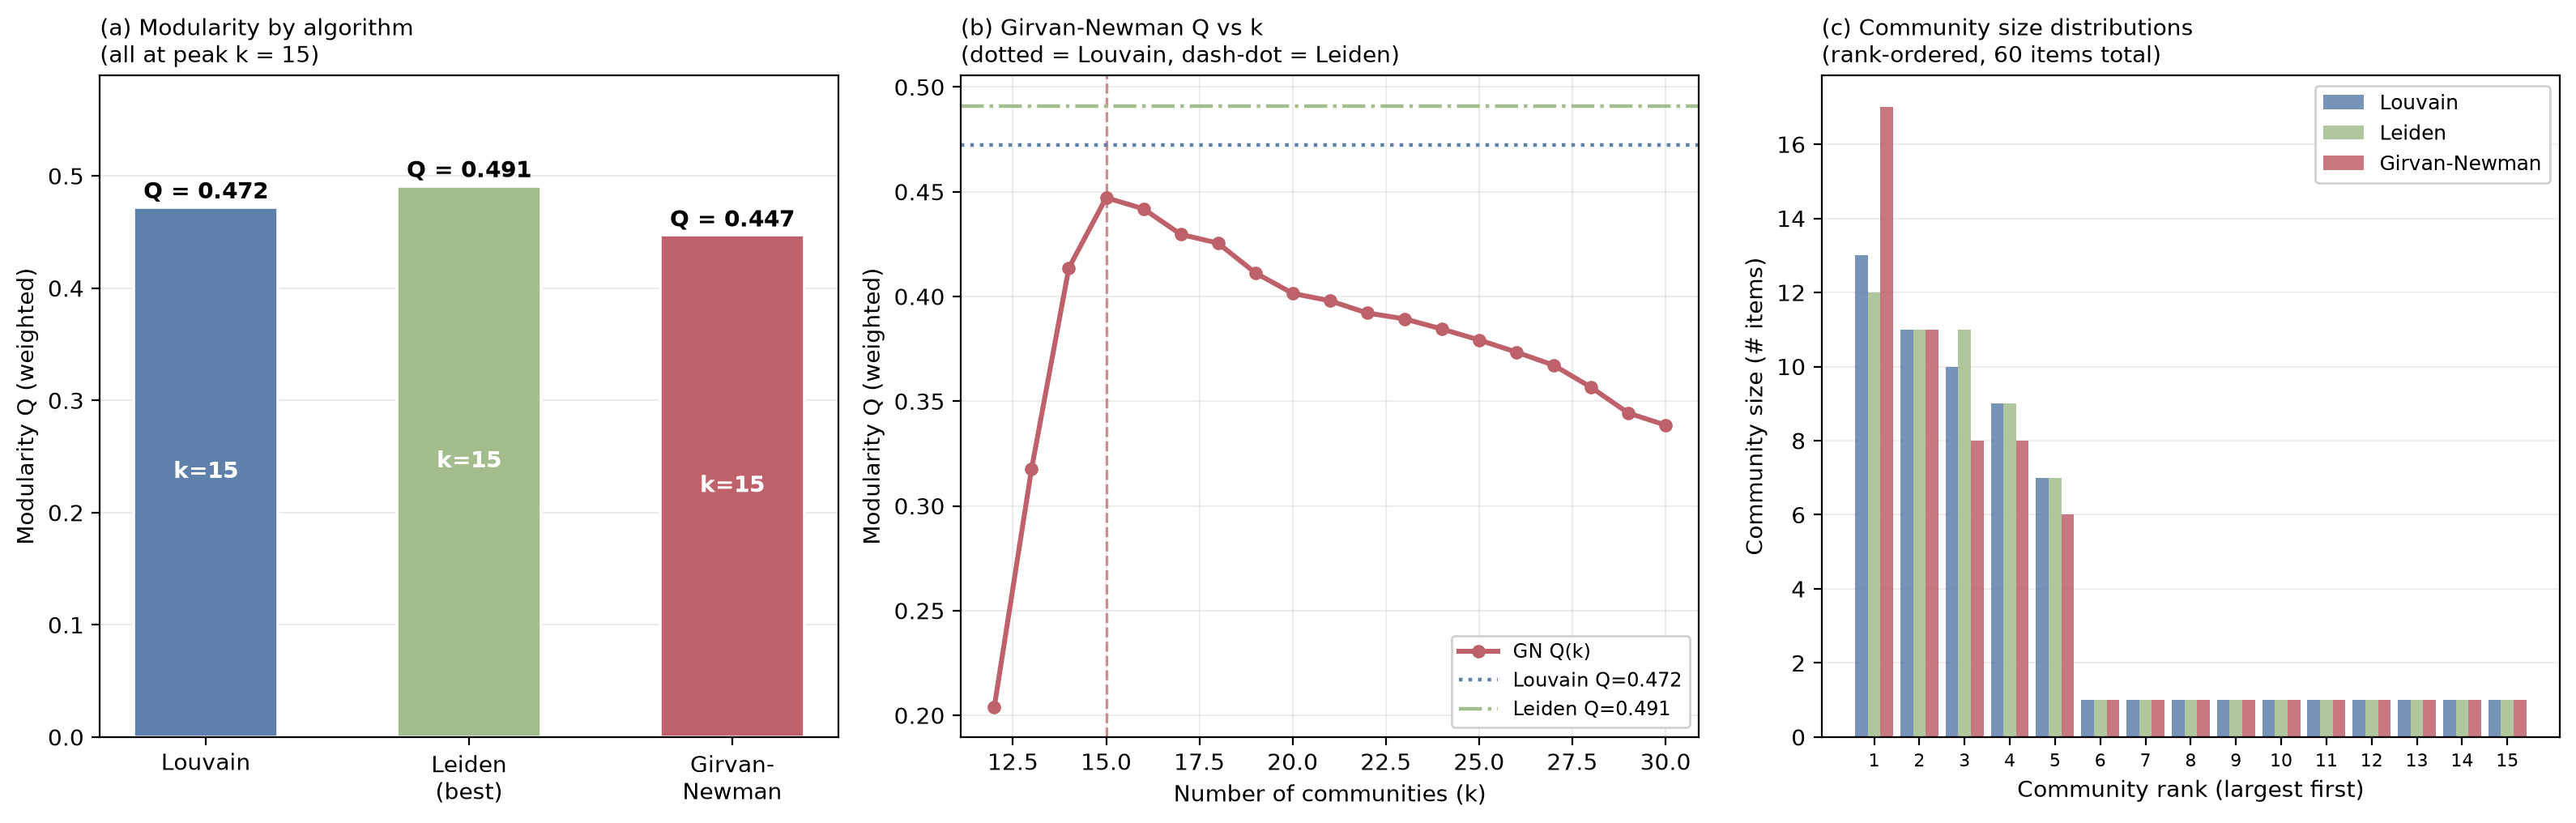

In [3]:
print("Three-algorithm comparison figure (modularity bar + GN Q(k) curve + community sizes):")
display(Image(filename=str(ROOT / "figures/person3/graph_10_algorithm_comparison.png")))

Main figure: Leiden community layout + null model comparison:


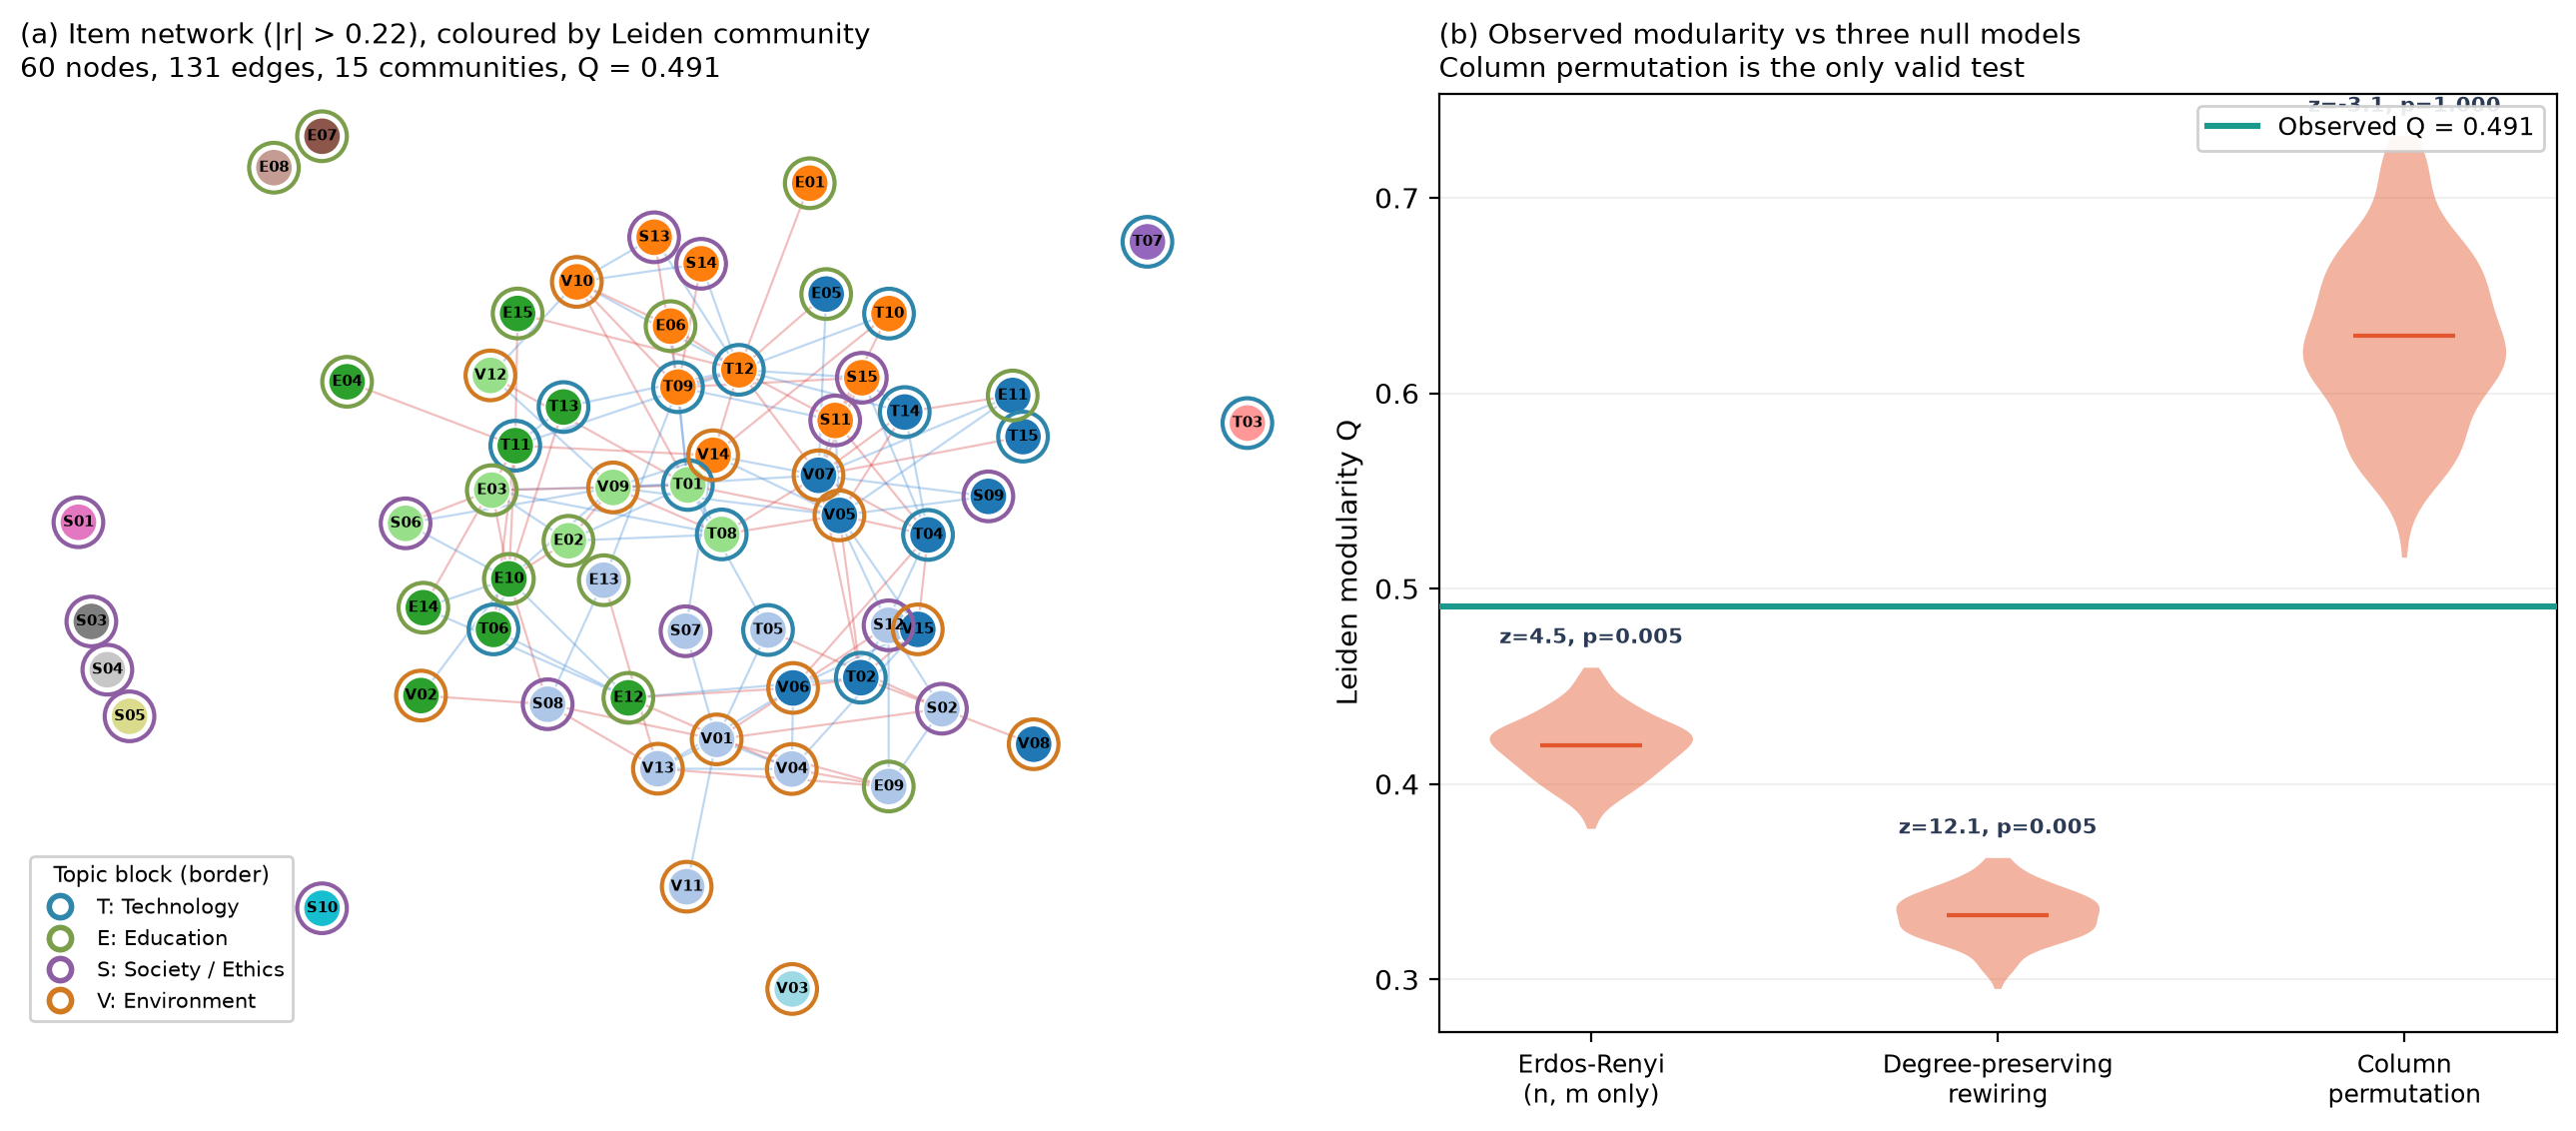

In [4]:
print("Main figure: Leiden community layout + null model comparison:")
display(Image(filename=str(ROOT / "figures/person3/graph_10_communities_nulls.png")))

In [5]:
print("=== Null Model Results (Leiden Q as observed) ===")
print(f"  Observed Q (Leiden): {stats_g10['Q_observed']:.4f}\n")
print(f"  {'Null model':<22} {'mean':>7} {'sd':>7} {'z':>8} {'p':>8} {'verdict'}")
print(f"  {'-'*65}")
for null_name, s in stats_g10['nulls'].items():
    verdict = "CLEARS" if s['z'] > 2 else "FAILS"
    print(f"  {null_name:<22} {s['null_mean']:>7.3f} {s['null_sd']:>7.3f} {s['z']:>8.2f} {s['p']:>8.3f}  {verdict}")
print(f"\n  NMI (communities vs topic blocks): {stats_g10['nmi_vs_topic_blocks']:.4f}")
print("  (NMI=0 means no alignment, NMI=1 means perfect match)")
print("  Low NMI confirms communities cut ACROSS the four survey topic domains.")

=== Null Model Results (Leiden Q as observed) ===
  Observed Q (Leiden): 0.4910

  Null model                mean      sd        z        p verdict
  -----------------------------------------------------------------
  permutation              0.629   0.044    -3.14    1.000  FAILS
  rewiring                 0.333   0.013    12.13    0.005  CLEARS
  er                       0.420   0.016     4.46    0.005  CLEARS

  NMI (communities vs topic blocks): 0.2046
  (NMI=0 means no alignment, NMI=1 means perfect match)
  Low NMI confirms communities cut ACROSS the four survey topic domains.


In [6]:
print("=== Girvan-Newman Q(k) Curve ===")
print(f"  {'k':>3}   {'Q':>7}")
for k, Q in stats_g10['gn_curve'][:20]:
    marker = " <-- PEAK" if Q == stats_g10['Q_girvan_newman'] else ""
    print(f"  {k:>3}   {Q:>7.4f}{marker}")

=== Girvan-Newman Q(k) Curve ===
    k         Q
   12    0.2040
   13    0.3177
   14    0.4136
   15    0.4471 <-- PEAK
   16    0.4419
   17    0.4297
   18    0.4255
   19    0.4113
   20    0.4015
   21    0.3979
   22    0.3921
   23    0.3893
   24    0.3845
   25    0.3792
   26    0.3734
   27    0.3672
   28    0.3567
   29    0.3443
   30    0.3386


---
## Graph 11: Structural Balance vs Threshold

Structural balance theory (Heider, 1946; Cartwright & Harary, 1956) predicts that a cognitively coherent social system should produce only balanced triads:
- **(+)(+)(+)**: "my friend's friend is my friend"
- **(+)(−)(−)**: "my enemy's enemy is my friend"

Unbalanced triads create cognitive dissonance. We test whether the signed opinion correlation network exhibits this property across all thresholds. The sign-permutation null tells us what balance fraction to expect by chance (~50%).

**Key finding**: The observed balance fraction monotonically approaches 100% as the threshold tightens (noise edges removed), far exceeding the ~50% null baseline. At the operating threshold of |r|>0.22, 100% of triads are balanced.

  computing structural balance across threshold sweep...


    threshold 0.14: 1359 triads, balanced = 0.988
    threshold 0.24: 33 triads, balanced = 1.000


    threshold 0.34: 1 triads, balanced = 1.000
    threshold 0.44: 0 triads, balanced = nan

  GRAPH 11 STRUCTURAL BALANCE
   threshold   triads   balanced  null mean        z
        0.05    12960      0.787      0.500    65.59
        0.06     9854      0.830      0.500    66.12
        0.07     7816      0.862      0.500    65.88
        0.08     6211      0.891      0.500    58.90
        0.09     4844      0.922      0.500    62.10
        0.10     3927      0.940      0.500    54.32
        0.11     3026      0.959      0.500    51.47
        0.12     2249      0.972      0.500    45.15
        0.13     1777      0.984      0.500    40.55
        0.14     1359      0.988      0.500    36.45
        0.15      983      0.991      0.500    33.61
        0.16      771      0.995      0.501    28.22
        0.17      581      0.997      0.500    23.18
        0.18      436      0.998      0.502    20.58
        0.19      291      0.997      0.500    17.10
        0.20      204      0.


  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_11_structural_balance.png / .pdf
  wrote artifacts/graph11_balance_stats.json


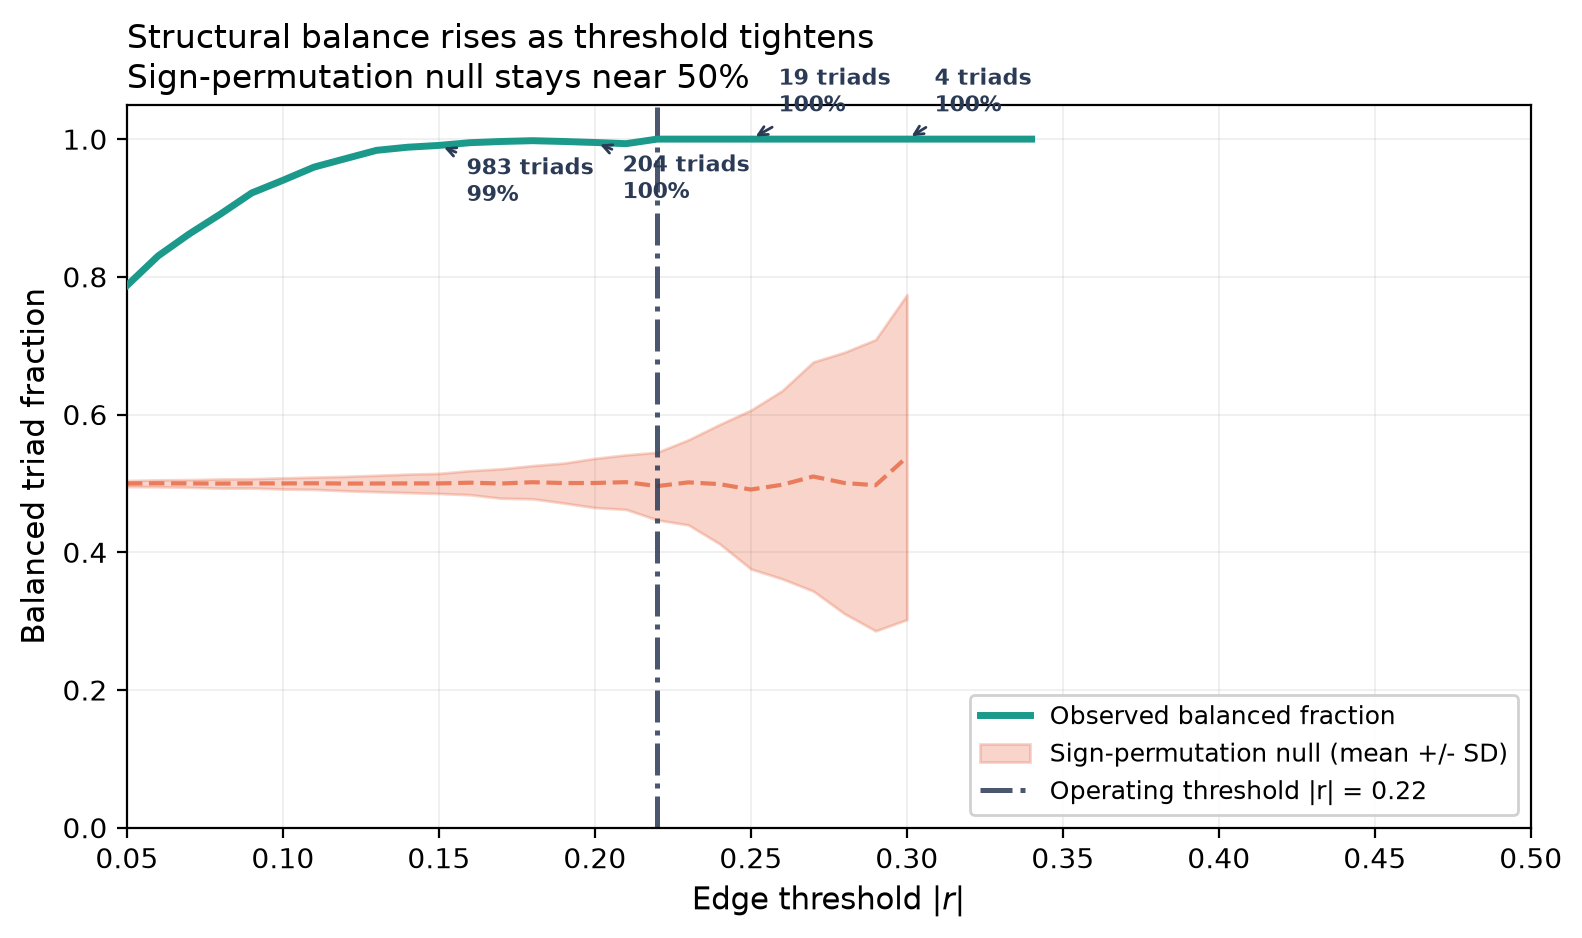

In [7]:
import src.person3.graph_11
importlib.reload(src.person3.graph_11)
from src.person3.graph_11 import run as run_g11

stats_g11 = run_g11()
display(Image(filename=str(ROOT / "figures/person3/graph_11_structural_balance.png")))

In [8]:
print("=== Structural Balance Summary ===")
print(f"  {'threshold':>10}  {'triads':>8}  {'balanced':>10}  {'null ~':>8}  {'z':>6}")
print(f"  {'-'*52}")
for r in stats_g11['sweep']:
    if r['threshold'] in (0.10, 0.15, 0.20, 0.22, 0.25, 0.30):
        z = r.get('z', float('nan'))
        z_str = f"{z:>6.1f}" if z == z else "   nan"
        print(f"  {r['threshold']:>10.2f}  {r['total_triads']:>8d}  {r['balanced_fraction']*100:>9.1f}%  {r['null_mean']*100:>7.1f}%  {z_str}")

=== Structural Balance Summary ===
   threshold    triads    balanced    null ~       z
  ----------------------------------------------------
        0.10      3927       94.0%     50.0%    54.3
        0.20       204       99.5%     50.1%    13.8


---
## Graph 6: Reordered Correlation Heatmap

The MP-denoised 60×60 correlation matrix is reordered by Leiden community assignment. This makes the block-diagonal structure visible. The marginal color strips show which predefined topic block (T/E/S/V) each item belongs to.

**What to look for**: Communities (bounded by black lines on the diagonal) should show strong red interior. The marginal strips reveal whether community members come from the same topic block (matching colors) or cross topic boundaries (mixed colors). Mixed colors confirm the low NMI observed in Graph 10.

  denoised matrix: (60, 60)
  60 items, 15 communities



  wrote /home/dev/Desktop/m26/dpcn/a1/dpcn_a1_opinion_network/figures/person3/graph_6_reordered_heatmap.png / .pdf


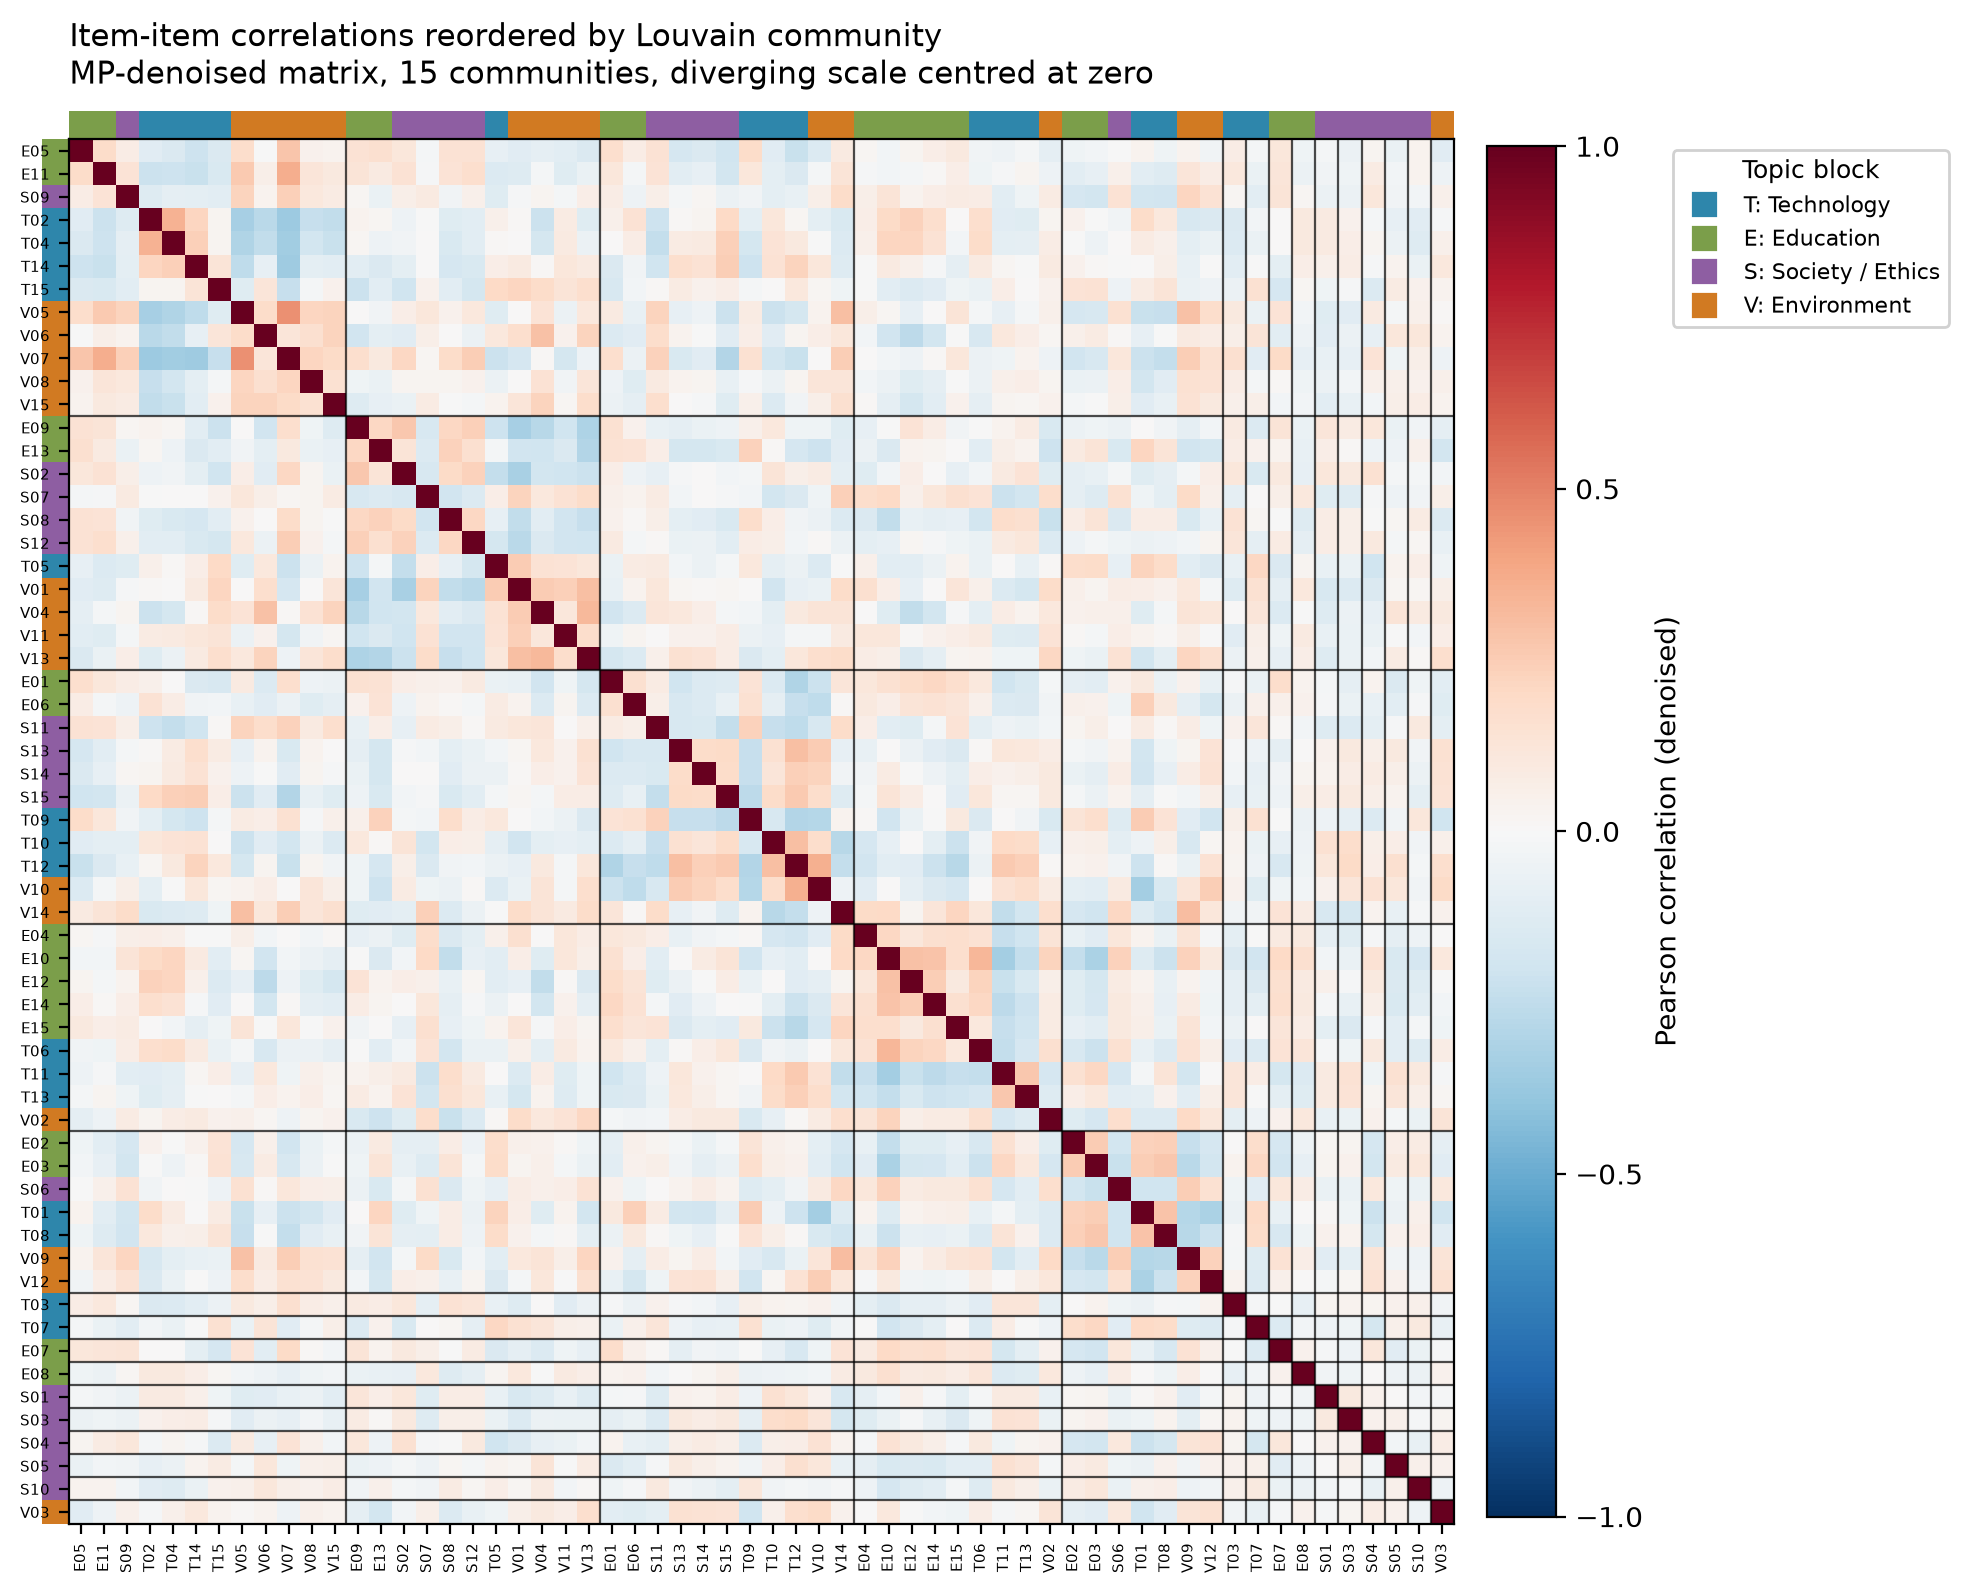

In [9]:
import src.person3.graph_6
importlib.reload(src.person3.graph_6)
from src.person3.graph_6 import run as run_g6

stats_g6 = run_g6()
display(Image(filename=str(ROOT / "figures/person3/graph_6_reordered_heatmap.png")))

---
## All Report Numbers (Summary)

In [10]:
print("=" * 60)
print("REPORT NUMBERS — Person 3")
print("=" * 60)

print("\n--- Graph 10: Community Detection ---")
print(f"  Louvain:        k={stats_g10['k_louvain']}, Q={stats_g10['Q_louvain']:.3f}")
print(f"  Leiden:         k={stats_g10['k_leiden']}, Q={stats_g10['Q_leiden']:.3f}  [PRIMARY]")
print(f"  Girvan-Newman:  k={stats_g10['k_girvan_newman']}, Q={stats_g10['Q_girvan_newman']:.3f}")
print(f"  NMI vs topic blocks: {stats_g10['nmi_vs_topic_blocks']:.3f}")

print("\n--- Graph 10: Null Model Z-Scores (Leiden Q as observed) ---")
for k, v in stats_g10['nulls'].items():
    print(f"  {k}: mean={v['null_mean']:.3f}, sd={v['null_sd']:.3f}, z={v['z']:.2f}, p={v['p']:.3f}")

print("\n--- Graph 11: Structural Balance ---")
for r in stats_g11['sweep']:
    if r['threshold'] in (0.15, 0.20, 0.22, 0.25):
        print(f"  |r|>{r['threshold']:.2f}: {r['balanced_fraction']*100:.0f}% balanced ({r['total_triads']} triads)")

REPORT NUMBERS — Person 3

--- Graph 10: Community Detection ---
  Louvain:        k=15, Q=0.472
  Leiden:         k=15, Q=0.491  [PRIMARY]
  Girvan-Newman:  k=15, Q=0.447
  NMI vs topic blocks: 0.205

--- Graph 10: Null Model Z-Scores (Leiden Q as observed) ---
  permutation: mean=0.629, sd=0.044, z=-3.14, p=1.000
  rewiring: mean=0.333, sd=0.013, z=12.13, p=0.005
  er: mean=0.420, sd=0.016, z=4.46, p=0.005

--- Graph 11: Structural Balance ---
  |r|>0.20: 100% balanced (204 triads)
